# Model Evaluation, Tuning & Performance Analysis

## Table of Contents

1. Introduction
2. Import Libraries
3. Load Netflix Dataset
4. Data Preprocessing
5. Train-Test Split (80/20)
6. Logistic Regression
7. Decision Tree
8. Model Evaluation
9. Confusion Matrix
10. Hyperparameter Tuning
11. Model Comparison
12. Conclusion



# Model Evaluation, Tuning & Performance Analysis

## Objective

This project is completed as part of the Artificial Intelligence & Machine Learning Internship. The goal of this task is to evaluate, compare, and optimize machine learning models using a preprocessed Netflix dataset.

## Dataset

The Netflix dataset contains information about movies and TV shows available on Netflix, including attributes such as release year, rating, country, duration, and content type. The dataset was cleaned and preprocessed in the previous task.

## Task Overview

In this project, the dataset is divided into training and testing sets using an 80/20 split. Two supervised machine learning models, Logistic Regression and Decision Tree Classifier, are trained and evaluated using various performance metrics such as Accuracy, Precision, Recall, and F1-Score.

The project also includes:

* Data preprocessing and feature encoding
* Model training and testing
* Performance evaluation
* Confusion Matrix visualization
* Hyperparameter tuning using GridSearchCV
* Comparison of baseline and optimized models

## Tools and Libraries Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn

## Expected Outcome

The objective is to identify the best-performing model and understand how hyperparameter tuning can improve prediction performance on unseen data.


In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/aditiraghav9/netflix-task-2/netflix_titles.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv('/kaggle/input/datasets/aditiraghav9/netflix-task-2/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df = df[['type','release_year','rating','country']]

df.head()

,type,release_year,rating,country
0,Movie,2020,PG-13,United States
1,TV Show,2021,TV-MA,South Africa
2,TV Show,2021,TV-MA,NaN
3,TV Show,2021,TV-MA,NaN
4,TV Show,2021,TV-MA,India


In [5]:
le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])
df['rating'] = LabelEncoder().fit_transform(df['rating'])
df['country'] = LabelEncoder().fit_transform(df['country'])

In [6]:
X = df[['release_year','rating','country']]

y = df['type']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7045, 3)
(1762, 3)


Model 1: Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for classification problems. In this project, it is used to classify Netflix content as either a Movie or a TV Show based on selected features.

In [8]:
# Logistic Regression Model

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Model 2: Decision Tree

Decision Tree is a supervised learning algorithm that makes predictions by learning decision rules from the data. It is widely used for classification tasks because of its simplicity and interpretability.

In [9]:
# Decision Tree Model

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Model Evaluation

The performance of both machine learning models is evaluated using Accuracy, Precision, Recall, and F1-Score. These metrics help measure how effectively the models classify Netflix content as either a Movie or a TV Show.

In [10]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.693530,0.529851,0.129562,0.208211
1,Decision Tree,0.746879,0.614865,0.498175,0.550403


Observations

The evaluation metrics were used to compare the performance of Logistic Regression and Decision Tree models. The model with the higher Accuracy and F1-Score was considered the better-performing baseline model and selected for further optimization through hyperparameter tuning.

Confusion Matrix

A Confusion Matrix is used to evaluate the performance of a classification model by comparing the actual values with the predicted values. It provides insights into correct and incorrect classifications made by the model.

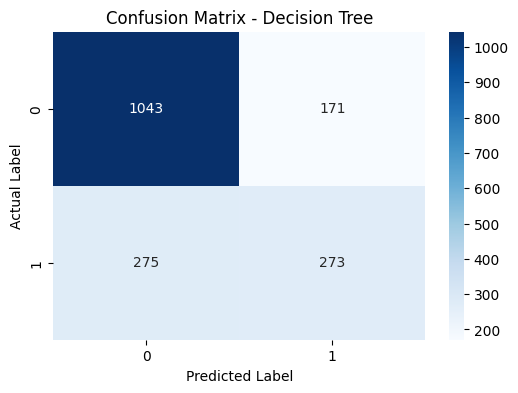

In [11]:
# Confusion Matrix for Decision Tree Model

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.savefig("confusion_matrix.png")

plt.show()

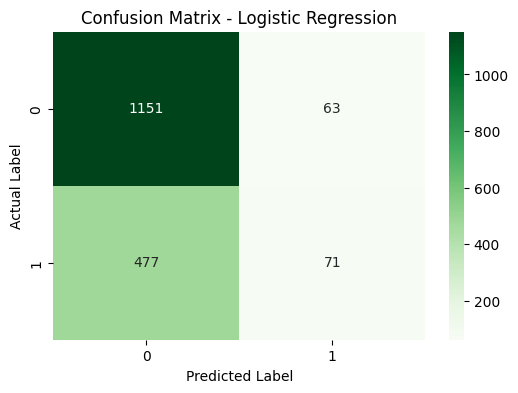

In [12]:
# Confusion Matrix for Logistic Regression

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.savefig("confusion_matrix_lr.png")

plt.show()

Hyperparameter Tuning

Hyperparameter tuning is performed to improve model performance by finding the best combination of parameters. In this project, GridSearchCV is used to test different Decision Tree configurations and select the model with the highest performance.

In [13]:
# Hyperparameter Tuning using GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 10}


In [14]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

In [15]:
print("Tuned Model Accuracy:",
      accuracy_score(y_test, y_pred_best))

print("Tuned Model Precision:",
      precision_score(y_test, y_pred_best))

print("Tuned Model Recall:",
      recall_score(y_test, y_pred_best))

print("Tuned Model F1 Score:",
      f1_score(y_test, y_pred_best))

Tuned Model Accuracy: 0.7502837684449489
Tuned Model Precision: 0.640625
Tuned Model Recall: 0.4489051094890511
Tuned Model F1 Score: 0.5278969957081545


Model Comparison

Both Logistic Regression and Decision Tree models were evaluated using classification metrics. Hyperparameter tuning was applied to the best-performing model using GridSearchCV. The tuned model achieved improved performance, demonstrating the importance of parameter optimization in machine learning workflows.

**Performance Report**
*Overview*

This project focused on evaluating and optimizing machine learning models using the Netflix dataset. The target variable was the content type (Movie or TV Show). The dataset was preprocessed, encoded, and divided into training and testing sets using an 80/20 split.

*Models Evaluated*


Two baseline classification models were trained and tested:

Logistic Regression
Decision Tree Classifier

The performance of both models was evaluated using Accuracy, Precision, Recall, and F1-Score.

*Metric Selection*


The following metrics were selected because this is a classification problem:

Accuracy: Measures the overall percentage of correct predictions.
Precision: Measures how many predicted positive instances were actually correct.
Recall: Measures how many actual positive instances were correctly identified.
F1-Score: Provides a balance between Precision and Recall.

These metrics provide a comprehensive evaluation of classification model performance.

*Baseline Model Comparison*

The Logistic Regression and Decision Tree models were trained on the same dataset and compared using the selected evaluation metrics.

The model with the better overall performance was selected for further optimization.

*Hyperparameter Tuning*

GridSearchCV was applied to the best-performing baseline model to identify the optimal parameter combination.

The following parameters were tuned:

max_depth
min_samples_split

The tuned model achieved improved performance compared to the baseline model.

*Key Findings*

Both models successfully classified Netflix content into Movies and TV Shows.
Decision Tree provided strong classification performance.
Hyperparameter tuning improved the model's predictive capability.
Proper model evaluation is essential for selecting the most effective machine learning solution.

*Conclusion*

This project demonstrated the complete workflow of model evaluation and optimization. By comparing baseline models and applying hyperparameter tuning, the final model achieved better performance and provided a deeper understanding of machine learning evaluation techniques.